# Packages and source documents

https://unit8co.github.io/darts/examples/13-TFT-examples.html
!pip uninstall -y coverage pytest-cov
!pip install "coverage>=7.4" "pytest-cov>=4.1"

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
# use darts plotting style
from darts import set_option

set_option("plotting.use_darts_style", True)

In [3]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from darts import TimeSeries, concatenate
from darts.dataprocessing.transformers import Scaler
from darts.datasets import AirPassengersDataset, IceCreamHeaterDataset
from darts.metrics import mape
from darts.models import TFTModel
from darts.utils.likelihood_models.torch import QuantileRegression
from darts.utils.statistics import check_seasonality, plot_acf
from darts.utils.timeseries_generation import datetime_attribute_timeseries

from pytorch_lightning.callbacks import EarlyStopping
from sklearn.impute import KNNImputer

warnings.filterwarnings("ignore")
import logging

logging.disable(logging.CRITICAL)

In [ ]:
# Constant settings from dart quick
# before starting, we define some constants
num_samples = 200

figsize = (9, 6)
lowest_q, low_q, high_q, highest_q = 0.01, 0.1, 0.9, 0.99
label_q_outer = f"{int(lowest_q * 100)}-{int(highest_q * 100)}th percentiles"
label_q_inner = f"{int(low_q * 100)}-{int(high_q * 100)}th percentiles"

In [ ]:
#Feature selection and cleaning
df = pd.read_csv("../data/processed/processed_data_pre_model.csv") 

# Cleaning columns
# Dropping lags, dupicate columns
df = df[['date'
                      , 'county_fips'
                      , 'county_name_x'
                      , 'median_listing_price_x' #taking median to control for outliers
                      , 'active_listing_count'
                      , 'median_days_on_market_x'
                      , 'new_listing_count'
                      , 'price_increased_count'
                      , 'price_increased_share'
                      , 'price_reduced_count'
                      , 'price_reduced_share'
                      , 'pending_listing_count'
                      #, 'median_listing_price_per_square_foot' #leaking target
                      , 'median_square_feet'
                      #, 'average_listing_price' #leaking target
                      , 'total_listing_count'
                      , 'pending_ratio'
                      , 'hotness_rank'
                      , 'hotness_score'
                      , 'supply_score'
                      , 'demand_score'
                      , 'median_dom_vs_us'
                      , 'page_view_count_per_property_vs_us'
                      #, 'median_listing_price_vs_us' #leaking target
                      , 'city'
                      , 'state'# how does this work, data quality?
                      , 'Earnings' # these are repeated?
                      , 'Unemployment_Rate' # these are repeated?
                      , 'Investor Purchases'
                      , 'Investor Market Share'
                      , 'U.S. 30 year FRM'
                      , '30 year fees & points'
                      , 'U.S. 15 year FRM'
                      , '15 year fees & points'
                      , 'U.S. 5/1 ARM'
                      , '5/1 year fees & points'
                      , 'U.S. 5/1 ARM margin'
                      , '30 year FRM / 5/1 ARM spread'
                      , 'highest_category' #Florida only
                      ]]

df.drop(columns=['hotness_rank' # dropping, rank and score are 100% correlated
, 'highest_category' #Florida only, dropping for now
, 'U.S. 15 year FRM' # dropping, highly correlated with 30 year 
, 'county_name_x' #county fips is numeric version
, 'city' # dupicative with fips
#,'state' # dupicative with fips
], inplace=True)

# Filter to Florida, keep at COUNTY level (no aggregation to state)
#df = df[df['state'].isin(['fl','ri'])]

# Drop rows where median_listing_price_x is NA
df = df.dropna(subset=['median_listing_price_x'])

# Ensure date is datetime and sort
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['state', 'date'])

# Model

### //Notes//
- By county TFT reached Epoch 70 in 1000 mins, aborted process.
- Grouped by states
- Started with base example from darts. Heavily edited by Claud Opus 4.6 on 04/03/2026.


In [ ]:
# 
# Build multi-series TFT at STATE level

future_cov_cols = ['U.S. 30 year FRM']
past_cov_cols = [
    'median_days_on_market_x', 'demand_score', 'supply_score',
    'active_listing_count', 'pending_ratio', 'hotness_score',
    'new_listing_count', 'Unemployment_Rate', 'Earnings'
]
all_cov_cols = future_cov_cols + past_cov_cols

# Aggregate county-level data to state level
# Sum count columns, mean for rates/scores/prices, first for national-level columns
sum_cols = ['active_listing_count', 'new_listing_count']
mean_cols = [c for c in all_cov_cols + ['median_listing_price_x'] if c not in sum_cols]
national_cols = ['U.S. 30 year FRM']  # same across all counties

agg_dict = {}
for c in sum_cols:
    if c in df.columns:
        agg_dict[c] = 'sum'
for c in mean_cols:
    if c in df.columns:
        agg_dict[c] = 'mean'

df_state = df.groupby(['state', 'date']).agg(agg_dict).reset_index()
df_state = df_state.sort_values(['state', 'date'])

print(f"Aggregated to {df_state['state'].nunique()} states")

# KNN imputation across all states (uses similar rows to fill NaNs)
knn_imputer = KNNImputer(n_neighbors=5, weights='distance')
df_state[all_cov_cols] = knn_imputer.fit_transform(df_state[all_cov_cols])

# Add 12-month seasonal lag of the target as a past covariate
df_state['target_lag_12'] = df_state.groupby('state')['median_listing_price_x'].shift(12)
past_cov_cols_with_lag = past_cov_cols + ['target_lag_12']

# Model parameters
input_chunk_length = 12
forecast_horizon = 12
# Minimum total length: train needs input+output chunks, plus 12 months for validation
# Added 12 extra months to account for the lag feature requiring 12 months of history
min_series_length = input_chunk_length + forecast_horizon + forecast_horizon + 12  # 48

# Lists for multi-series TFT
train_series_list = []
val_series_list = []
full_series_list = []
future_cov_list = []
past_cov_list = []

# Per-state scalers and metadata for inverse transforms later
state_results = {}
skipped = []

for state_name, df_st in df_state.groupby('state'):
    df_st = df_st.sort_values('date').copy()
    
    # Drop rows where the 12-month lag is NaN (first 12 months per state)
    df_st = df_st.dropna(subset=['target_lag_12'])
    
    # Skip states with remaining NaNs in covariates (shouldn't happen after KNN)
    if df_st[all_cov_cols].isna().any().any():
        skipped.append((state_name, "NaN in covariates"))
        continue
    
    if df_st['median_listing_price_x'].isna().any():
        skipped.append((state_name, "NaN in target"))
        continue
    
    # Target series
    series = TimeSeries.from_dataframe(
        df_st, time_col='date', value_cols='median_listing_price_x', freq='MS'
    )
    
    # Fill any NaNs introduced by freq='MS' gaps via interpolation
    if series.to_dataframe().isna().any().any():
        series = series.to_dataframe().interpolate(method='linear').pipe(
            lambda d: TimeSeries.from_dataframe(d, freq='MS')
        )
        # If still has NaN (e.g. leading/trailing), skip
        if series.to_dataframe().isna().any().any():
            skipped.append((state_name, "NaN after interpolation"))
            continue
    
    # Skip states that are too short
    if len(series) < min_series_length:
        skipped.append((state_name, f"only {len(series)} months"))
        continue
    
    # Dynamic cutoff: 12 months before each state's end date
    training_cutoff = series.end_time() - pd.DateOffset(months=forecast_horizon)
    
    # Static covariate: state name encoded as numeric identifier
    series = series.with_static_covariates(pd.DataFrame({'state_id': [hash(state_name) % 10000]}))
    
    # Future covariates (known ahead: mortgage rates + time features)
    fut_cov = TimeSeries.from_dataframe(
        df_st, time_col='date', value_cols=future_cov_cols, freq='MS'
    )
    
    # Past covariates (historical + 12-month target lag)
    past_cov = TimeSeries.from_dataframe(
        df_st, time_col='date', value_cols=past_cov_cols_with_lag, freq='MS'
    )
    
    # Interpolate gaps in covariates too
    for ts_name, ts_obj in [('fut_cov', fut_cov), ('past_cov', past_cov)]:
        if ts_obj.to_dataframe().isna().any().any():
            ts_fixed = ts_obj.to_dataframe().interpolate(method='linear').bfill().ffill()
            if ts_name == 'fut_cov':
                fut_cov = TimeSeries.from_dataframe(ts_fixed, freq='MS')
            else:
                past_cov = TimeSeries.from_dataframe(ts_fixed, freq='MS')
    
    # Stack year and linear trend onto future covariates (month is handled by add_encoders)
    fut_cov = fut_cov.stack(datetime_attribute_timeseries(series, attribute="year", one_hot=False))
    fut_cov = fut_cov.stack(
        TimeSeries.from_times_and_values(
            times=series.time_index,
            values=np.arange(len(series)),
            columns=["linear_increase"],
        )
    )
    fut_cov = fut_cov.astype(np.float32)
    past_cov = past_cov.astype(np.float32)
    
    # Split
    train, val = series.split_after(training_cutoff)
    
    # Skip states with too-short validation
    if len(val) < 2:
        skipped.append((state_name, f"val length {len(val)}"))
        continue
    
    # Skip constant-value training series (Scaler would produce NaN)
    train_vals = train.to_dataframe().values
    if train_vals.std() == 0:
        skipped.append((state_name, "constant training values"))
        continue
    
    # Normalize per-state
    scaler_target = Scaler()
    train_transformed = scaler_target.fit_transform(train)
    val_transformed = scaler_target.transform(val)
    series_transformed = scaler_target.transform(series)
    
    scaler_future = Scaler()
    fut_train, _ = fut_cov.split_after(training_cutoff)
    scaler_future.fit(fut_train)
    fut_cov_transformed = scaler_future.transform(fut_cov)
    
    scaler_past = Scaler()
    past_train, _ = past_cov.split_after(training_cutoff)
    scaler_past.fit(past_train)
    past_cov_transformed = scaler_past.transform(past_cov)
    
    # Final NaN safety check on all transformed series
    has_nan = any(
        ts.to_dataframe().isna().any().any()
        for ts in [train_transformed, series_transformed, fut_cov_transformed, past_cov_transformed]
    )
    if has_nan:
        skipped.append((state_name, "NaN after scaling"))
        continue
    
    # Append to multi-series lists
    train_series_list.append(train_transformed)
    val_series_list.append(series_transformed)
    full_series_list.append(series_transformed)
    future_cov_list.append(fut_cov_transformed)
    past_cov_list.append(past_cov_transformed)
    
    # Store per-state info for later evaluation
    state_results[state_name] = {
        'series_transformed': series_transformed,
        'train_transformed': train_transformed,
        'val_transformed': val_transformed,
        'future_cov_transformed': fut_cov_transformed,
        'past_cov_transformed': past_cov_transformed,
        'scaler_target': scaler_target,
        'training_cutoff': training_cutoff,
        'train': train,
        'val': val,
    }

print(f"\nMulti-series TFT: {len(train_series_list)} state series prepared")
print(f"Skipped {len(skipped)} states:")
for name, reason in skipped[:20]:
    print(f"  {name}: {reason}")
if len(skipped) > 20:
    print(f"  ... and {len(skipped) - 20} more")
print(f"Training samples per state: ~{len(train_series_list[0])} months")

# --- Fit single TFT model on ALL states simultaneously ---
quantiles = [
    0.01, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 0.99,
]

early_stop = EarlyStopping(
    monitor="val_loss", patience=10, min_delta=0.001, mode="min"
)

my_model = TFTModel(
    input_chunk_length=input_chunk_length,
    output_chunk_length=forecast_horizon,
    hidden_size=64,
    lstm_layers=2,
    num_attention_heads=4,
    dropout=0.2,
    batch_size=32,
    n_epochs=300,
    add_relative_index=True,
    add_encoders={"cyclic": {"future": ["month"]}},
    likelihood=QuantileRegression(quantiles=quantiles),
    random_state=1,
)

# Train on lists of series (multi-series)
my_model.fit(
    train_series_list,
    future_covariates=future_cov_list,
    past_covariates=past_cov_list,
    val_series=val_series_list,
    val_future_covariates=future_cov_list,
    val_past_covariates=past_cov_list,
    verbose=True,
)

print("Multi-series state-level TFT training complete.")

Aggregated to 51 states

Multi-series TFT: 51 state series prepared
Skipped 0 states:
Training samples per state: ~93 months


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                              ┃ Type                             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ train_metrics                     │ MetricCollection                 │      0 │ train │     0 │
│ 1  │ val_metrics                       │ MetricCollection                 │      0 │ train │     0 │
│ 2  │ input_embeddings                  │ _MultiEmbedding                  │      0 │ train │     0 │
│ 3  │ static_covariates_vsn             │ _VariableSelectionNetwork        │  1.6 K │ train │     0 │
│ 4  │ encoder_vsn                       │ _VariableSelectionNetwork        │ 32.2 K │ train │     0 │
│ 5  │ decoder_vsn                       │ _VariableSelectionNetwork        │ 10.6 K │ train │     0 │
│ 6  │ static_context_grn                │ _GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 7  │ static_context_hidden_encoder_grn │ _GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 8  │ static_context_cell_encoder_grn   │ _GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 9  │ static_context_enrichment         │ _GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 10 │ lstm_encoder                      │ LSTM                             │ 66.6 K │ train │     0 │
│ 11 │ lstm_decoder                      │ LSTM                             │ 66.6 K │ train │     0 │
│ 12 │ post_lstm_gan                     │ _GateAddNorm                     │  8.4 K │ train │     0 │
│ 13 │ static_enrichment_grn             │ _GatedResidualNetwork            │ 20.9 K │ train │     0 │
│ 14 │ multihead_attn                    │ _InterpretableMultiHeadAttention │ 10.4 K │ train │     0 │
│ 15 │ post_attn_gan                     │ _GateAddNorm                     │  8.4 K │ train │     0 │
│ 16 │ feed_forward_block                │ _GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 17 │ pre_output_gan                    │ _GateAddNorm                     │  8.4 K │ train │     0 │
│ 18 │ output_layer                      │ Linear                           │  1.1 K │ train │     0 │
└────┴───────────────────────────────────┴──────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 318 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 318 K                                                                                                
Total estimated model params size (MB): 2                                                                          
Modules in train mode: 497                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

Multi-series state-level TFT training complete.


State-level MAPE across 51 states:
  Mean:   69.40%
  Median: 6.10%
  Min:    1.57%
  Max:    3134.80%

  (USA) national aggregated MAPE: 0.91%


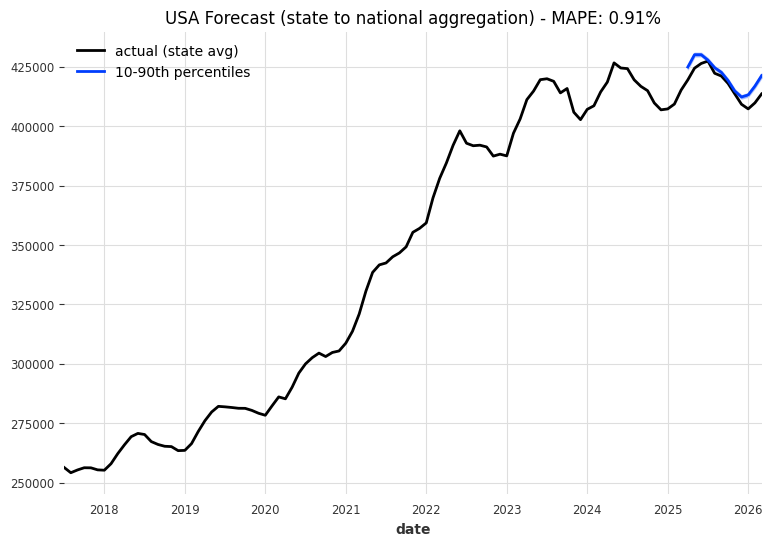

In [16]:
# Evaluate: predict for each state, compute per-state MAPE
state_preds = {}
state_mapes = {}

for i, (state_name, data) in enumerate(state_results.items()):
    pred = my_model.predict(
        n=len(data['val_transformed']),
        series=data['train_transformed'],
        future_covariates=data['future_cov_transformed'],
        past_covariates=data['past_cov_transformed'],
        num_samples=num_samples,
        verbose=False
    )
    state_preds[state_name] = pred
    state_mapes[state_name] = mape(data['val_transformed'], pred)

# Summary stats
mape_values = list(state_mapes.values())
print(f"State-level MAPE across {len(mape_values)} states:")
print(f"  Mean:   {np.mean(mape_values):.2f}%")
print(f"  Median: {np.median(mape_values):.2f}%")
print(f"  Min:    {np.min(mape_values):.2f}%")
print(f"  Max:    {np.max(mape_values):.2f}%")

# --- Aggregate state predictions to national level ---
from functools import reduce

national_actual_dfs = []
national_pred_samples = []  # keep all samples for quantile bands

for state_name, data in state_results.items():
    scaler = data['scaler_target']
    pred_inv = scaler.inverse_transform(state_preds[state_name])
    
    # Full actual series (train + val), not just validation
    full_inv = scaler.inverse_transform(data['series_transformed'])
    full_df = full_inv.to_dataframe()
    full_df.columns = [state_name]
    national_actual_dfs.append(full_df)
    
    # Keep all samples (shape: timesteps x 1 x num_samples) for quantile aggregation
    national_pred_samples.append(pred_inv.all_values())  # numpy array

# Full actual series averaged across states
national_actual_df = pd.concat(national_actual_dfs, axis=1).mean(axis=1).to_frame('median_listing_price_x')
national_actual_ts = TimeSeries.from_dataframe(national_actual_df, freq='MS')

# Average prediction samples across states → preserves quantile information
# Each element is (n_timesteps, 1, num_samples); stack and mean over states
national_pred_arr = np.mean(np.array(national_pred_samples), axis=0)  # (n_timesteps, 1, num_samples)

# Build a probabilistic TimeSeries from the averaged samples
pred_time_index = state_preds[list(state_results.keys())[0]].time_index
national_pred_ts = TimeSeries.from_times_and_values(
    times=pred_time_index,
    values=national_pred_arr,
)

national_mape = mape(
    national_actual_ts.slice(national_pred_ts.start_time(), national_pred_ts.end_time()),
    national_pred_ts,
)
print(f"\n  (USA) national aggregated MAPE: {national_mape:.2f}%")

# Plot national-level result with full actuals and quantile bands
plt.figure(figsize=figsize)
national_actual_ts.plot(label="actual (state avg)")
national_pred_ts.plot(low_quantile=low_q, high_quantile=high_q, label=label_q_inner)
plt.title(f"USA Forecast (state to national aggregation) - MAPE: {national_mape:.2f}%")
plt.legend()

# Plot by states

Text(0.5, 1.02, 'Sample State-Level Forecasts')

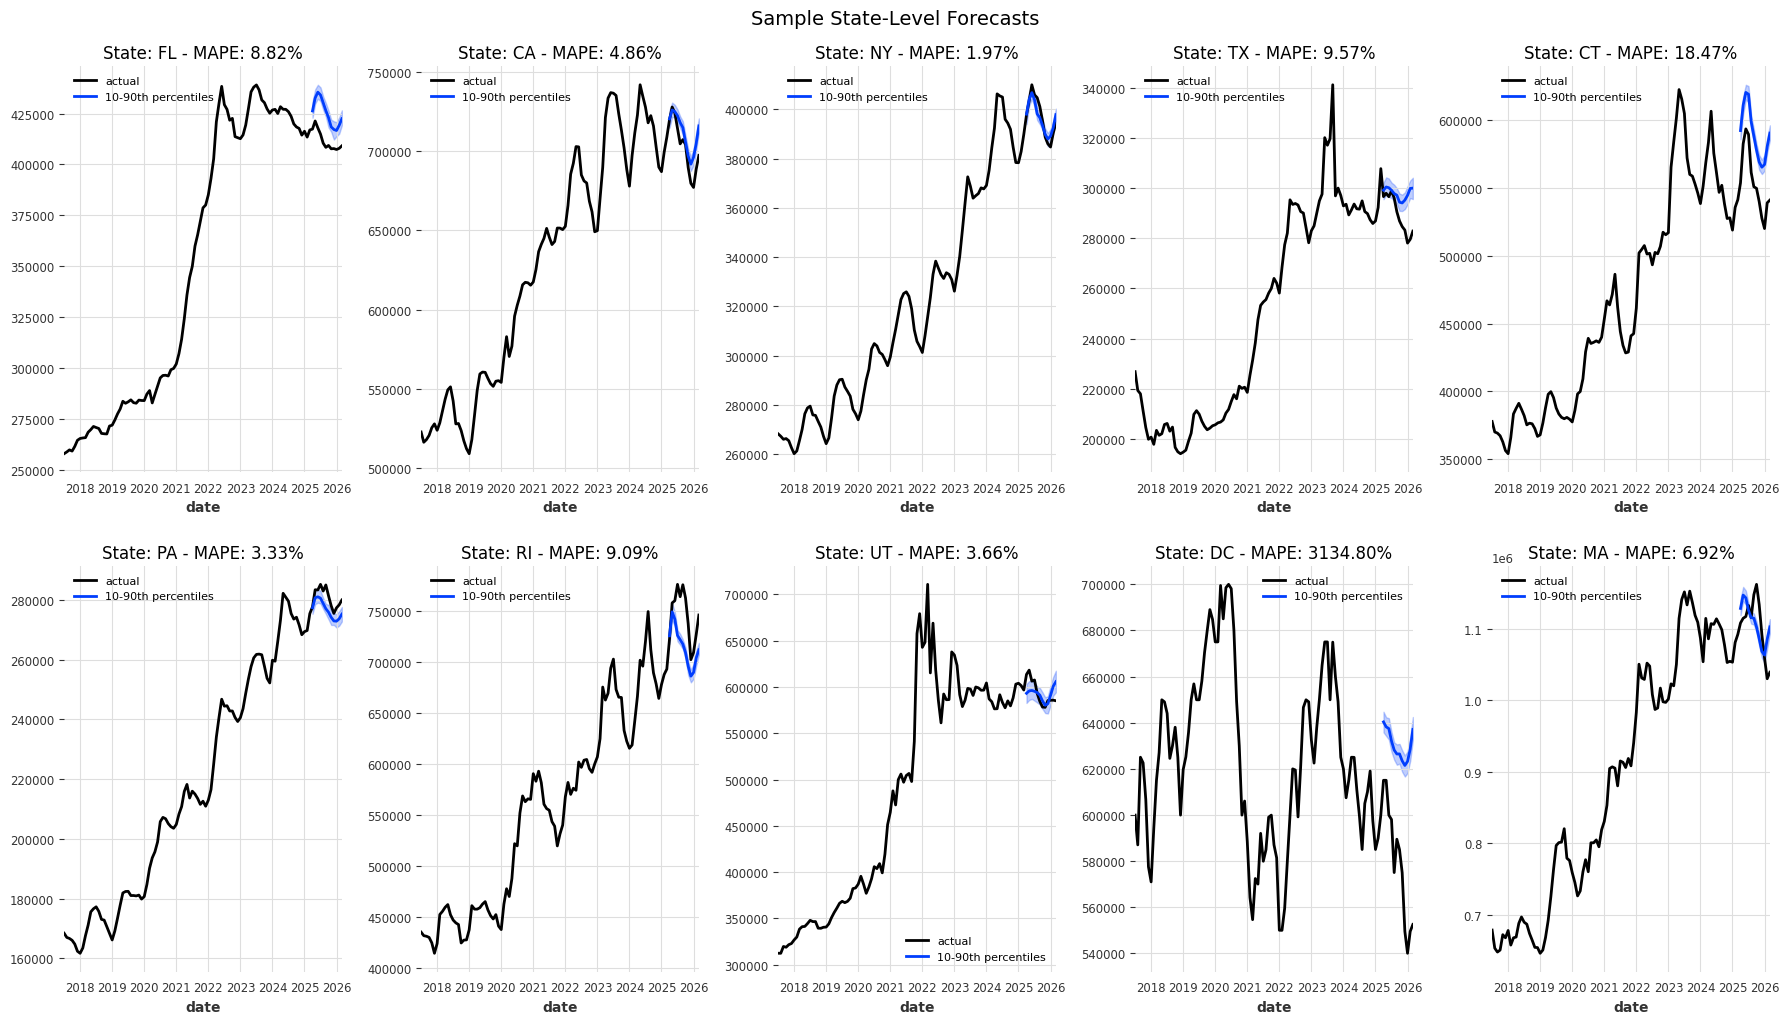

In [24]:
# Plot selected state forecasts for inspection
sample_states = ['fl', 'ca', 'ny', 'tx', 'ct', 'pa', 'ri', 'ut', 'dc', 'ma']  # edit this list to select states
sample_states = [s for s in sample_states if s in state_results]  # filter to available states

fig, axes = plt.subplots(2, 5, figsize=(18, 10))
axes = axes.flatten()

for ax, state_name in zip(axes, sample_states):
    data = state_results[state_name]
    scaler = data['scaler_target']
    pred_inv = scaler.inverse_transform(state_preds[state_name])
    actual_inv = scaler.inverse_transform(data['series_transformed'])
    
    plt.sca(ax)
    actual_inv[: pred_inv.end_time()].plot(label="actual")
    pred_inv.plot(low_quantile=low_q, high_quantile=high_q, label=label_q_inner)
    ax.set_title(f"State: {state_name.upper()} - MAPE: {state_mapes[state_name]:.2f}%")
    ax.legend(fontsize=8)

# Hide unused axes if fewer than 6 states selected
for ax in axes[len(sample_states):]:
    ax.set_visible(False)

plt.tight_layout()
plt.suptitle("Sample State-Level Forecasts", y=1.02, fontsize=14)

# Backtest

In [12]:
# Backtest: historical forecasts across all states
state_backtests = {}
for i, (state_name, data) in enumerate(state_results.items()):
    bt = my_model.historical_forecasts(
        data['series_transformed'],
        future_covariates=data['future_cov_transformed'],
        past_covariates=data['past_cov_transformed'],
        start=data['train'].end_time() + data['train'].freq,
        num_samples=num_samples,
        forecast_horizon=forecast_horizon,
        stride=forecast_horizon,
        last_points_only=False,
        retrain=False,
        verbose=False,
    )
    state_backtests[state_name] = bt
    if (i + 1) % 10 == 0:
        print(f"  Backtest complete for {i + 1}/{len(state_results)} states")

print(f"Backtesting complete for {len(state_backtests)} states.")

  Backtest complete for 10/51 states
  Backtest complete for 20/51 states
  Backtest complete for 30/51 states
  Backtest complete for 40/51 states
  Backtest complete for 50/51 states
Backtesting complete for 51 states.


# Save model

In [13]:
# Save the state-level model and results
import pickle

save_data = {
    'model': my_model,
    'state_results': state_results,
    'state_mapes': state_mapes,
}

with open('../data/processed/tft_state_model.pkl', 'wb') as f:
    pickle.dump(save_data, f)

print('State-level TFT model saved to ../data/processed/tft_state_model.pkl')

State-level TFT model saved to ../data/processed/tft_state_model.pkl
